# Deep Learning Pipeline for Out-of-Band Spectral Classification

This notebook implements a reproducible 1D deep learning workflow to classify linear vs nonlinear SRRC-BPSK signals using **only out-of-band spectral information**. The experiments mirror the thesis hypothesis that weak, distributed nonlinear structure in spectral regrowth bins can be learned more effectively than by a simple threshold test and potentially compared against strong traditional baselines.

## Section 0 — Imports and Constants

This section defines all dependencies, reproducibility controls, and experiment constants used throughout the notebook.

In [14]:
# Section 0: Import libraries, define constants, and set random seeds
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, confusion_matrix
)

# Constants
BAND_EDGE        = 49
REGROWTH_START   = 50
ANALYSIS_END     = 150
FULL_END         = 799
MAIN_LOBE_START  = 5
MAIN_LOBE_END    = 49
N_BINS           = 800
LABEL_COL        = "nonlinear"
TEST_SIZE        = 0.15
VAL_SIZE         = 0.15
RANDOM_STATE     = 42
CSV_PATH         = os.path.join(os.path.dirname(os.getcwd()), "data", "data.csv")
DROPOUT_RATE     = 0.3
EPOCHS           = 200
BATCH_SIZE       = 32
LEARNING_RATE    = 1e-4
PATIENCE         = 20

# Reproducibility
random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)
torch.manual_seed(RANDOM_STATE)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(RANDOM_STATE)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

## Section 1 — Data Loading and Validation

The dataset is loaded from `data.csv`. Features are selected strictly by **column position** (0 to 799), and labels are read from `nonlinear`. A single stratified 70/15/15 split is created once and reused for all experiments to ensure fair model comparison.

In [15]:
# Section 1: Load data by position, validate class balance, and create one reusable split
df = pd.read_csv(CSV_PATH)

if df.shape[1] != N_BINS + 1:
    raise ValueError(f"Expected {N_BINS + 1} columns, found {df.shape[1]}")
if LABEL_COL not in df.columns:
    raise ValueError(f"Missing label column '{LABEL_COL}'")

X_all_bins = df.iloc[:, 0:N_BINS].to_numpy(dtype=np.float32)
y = df[LABEL_COL].to_numpy(dtype=np.int64)

class_counts = pd.Series(y).value_counts().sort_index()
print("Class distribution (0=linear, 1=nonlinear):")
print(class_counts.to_string())

indices = np.arange(len(y))
train_idx, temp_idx = train_test_split(
    indices,
    test_size=(VAL_SIZE + TEST_SIZE),
    stratify=y,
    random_state=RANDOM_STATE
)

temp_y = y[temp_idx]
val_relative = VAL_SIZE / (VAL_SIZE + TEST_SIZE)
val_idx, test_idx = train_test_split(
    temp_idx,
    test_size=(1 - val_relative),
    stratify=temp_y,
    random_state=RANDOM_STATE
)

print(f"Total samples: {len(y)}")
print(f"Train size: {len(train_idx)} ({len(train_idx)/len(y):.2%})")
print(f"Val size:   {len(val_idx)} ({len(val_idx)/len(y):.2%})")
print(f"Test size:  {len(test_idx)} ({len(test_idx)/len(y):.2%})")

for split_name, split_idx in [("train", train_idx), ("val", val_idx), ("test", test_idx)]:
    counts = pd.Series(y[split_idx]).value_counts().sort_index()
    print(f"{split_name} class counts: {counts.to_dict()}")

Class distribution (0=linear, 1=nonlinear):
0    5000
1    5000
Total samples: 10000
Train size: 7000 (70.00%)
Val size:   1500 (15.00%)
Test size:  1500 (15.00%)
train class counts: {0: 3500, 1: 3500}
val class counts: {0: 750, 1: 750}
test class counts: {0: 750, 1: 750}


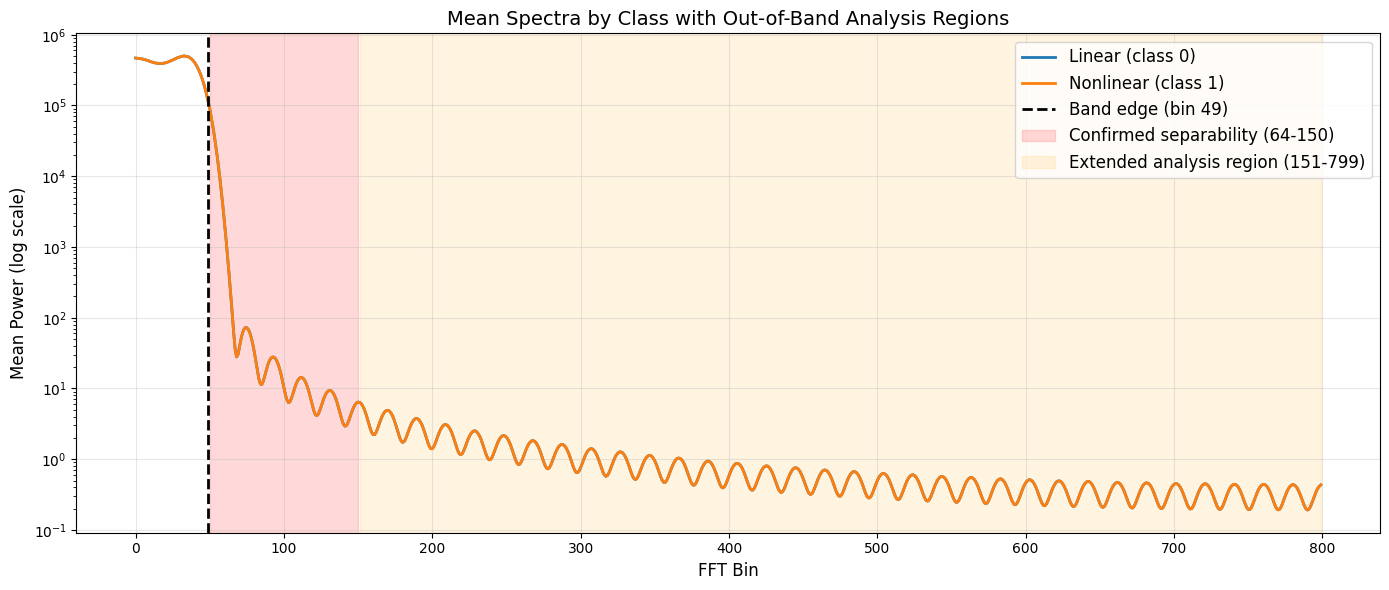

In [16]:
# Section 1: Plot mean class spectra with in-band boundary and out-of-band analysis regions
plt.figure(figsize=(14, 6))
mean_linear = X_all_bins[y == 0].mean(axis=0)
mean_nonlinear = X_all_bins[y == 1].mean(axis=0)
bins = np.arange(N_BINS)

plt.plot(bins, mean_linear, label='Linear (class 0)', linewidth=2)
plt.plot(bins, mean_nonlinear, label='Nonlinear (class 1)', linewidth=2)

plt.axvline(BAND_EDGE, color='black', linestyle='--', linewidth=2, label=f'Band edge (bin {BAND_EDGE})')
plt.axvspan(REGROWTH_START, ANALYSIS_END, color='red', alpha=0.15, label='Confirmed separability (64-150)')
plt.axvspan(ANALYSIS_END + 1, FULL_END, color='orange', alpha=0.12, label='Extended analysis region (151-799)')

plt.yscale('log')
plt.xlabel('FFT Bin', fontsize=12)
plt.ylabel('Mean Power (log scale)', fontsize=12)
plt.title('Mean Spectra by Class with Out-of-Band Analysis Regions', fontsize=14)
plt.legend(fontsize=12)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Section 2 — Engineered Features

This section computes six scalar engineered descriptors from out-of-band bins only (`64–799`). These are used in selected DNN experiments and sanity-checked using Cohen's $d$ between classes to confirm weak univariate separability.

In [17]:
# Section 2: Compute engineered out-of-band features and Cohen's d sanity checks
oob = X_all_bins[:, REGROWTH_START:FULL_END + 1]
regrowth_region = X_all_bins[:, REGROWTH_START:ANALYSIS_END + 1]
main_lobe_region = X_all_bins[:, MAIN_LOBE_START:MAIN_LOBE_END + 1]
bin_idx_oob = np.arange(REGROWTH_START, FULL_END + 1, dtype=np.float32)

regrowth_power = regrowth_region.sum(axis=1)

spectral_slope = np.array([
    np.polyfit(bin_idx_oob, row, 1)[0] for row in oob
], dtype=np.float32)

oob_sum = oob.sum(axis=1, keepdims=True)
p = oob / (oob_sum + 1e-10)
spectral_entropy = -np.sum(p * np.log(p + 1e-10), axis=1)

spectral_flatness = np.exp(np.mean(np.log(oob + 1e-10), axis=1)) / (np.mean(oob, axis=1) + 1e-10)

acpr_ratio = regrowth_region.sum(axis=1) / (main_lobe_region.sum(axis=1) + 1e-10)
acpr_db = 10.0 * np.log10(np.clip(acpr_ratio, 1e-10, None))

oob_mean = oob.mean(axis=1, keepdims=True)
oob_std = oob.std(axis=1, keepdims=True)
spectral_kurtosis = np.mean((oob - oob_mean) ** 4, axis=1) / (oob_std.squeeze() ** 4 + 1e-10)

engineered_features = np.column_stack([
    regrowth_power.astype(np.float32),
    spectral_slope.astype(np.float32),
    spectral_entropy.astype(np.float32),
    spectral_flatness.astype(np.float32),
    acpr_db.astype(np.float32),
    spectral_kurtosis.astype(np.float32)
])

engineered_feature_names = [
    'regrowth_power',
    'spectral_slope',
    'spectral_entropy',
    'spectral_flatness',
    'acpr_db',
    'spectral_kurtosis'
]

print(f"engineered_features shape: {engineered_features.shape}")

def cohens_d(x0, x1):
    n0, n1 = len(x0), len(x1)
    v0, v1 = np.var(x0, ddof=1), np.var(x1, ddof=1)
    pooled = np.sqrt(((n0 - 1) * v0 + (n1 - 1) * v1) / (n0 + n1 - 2) + 1e-10)
    return (np.mean(x1) - np.mean(x0)) / pooled

print("Cohen's d by engineered feature:")
for idx, name in enumerate(engineered_feature_names):
    d_val = cohens_d(engineered_features[y == 0, idx], engineered_features[y == 1, idx])
    print(f"  {name:20s}: {d_val:.6f}")

engineered_features shape: (10000, 6)
Cohen's d by engineered feature:
  regrowth_power      : 0.023683
  spectral_slope      : -0.023419
  spectral_entropy    : 0.030355
  spectral_flatness   : -0.010961
  acpr_db             : 0.025923
  spectral_kurtosis   : -0.009126


## Section 3 — Model Architectures

This section defines the six required experiment configurations, the dynamic-depth 1D CNN, the fully connected DNN, and an early stopping utility for robust model selection on validation loss.

In [18]:
# Section 3: Define experiment list, CNN/DNN architectures, and early stopping
experiments = [
    {"id": 1, "model_type": "CNN", "bins": (64, 799), "use_engineered": False},
    {"id": 2, "model_type": "CNN", "bins": (64, 150), "use_engineered": False},
    {"id": 3, "model_type": "DNN", "bins": (64, 799), "use_engineered": False},
    {"id": 4, "model_type": "DNN", "bins": (64, 799), "use_engineered": True},
    {"id": 5, "model_type": "DNN", "bins": (64, 150), "use_engineered": False},
    {"id": 6, "model_type": "DNN", "bins": (64, 150), "use_engineered": True},
]

def init_weights(m):
    if isinstance(m, (nn.Linear, nn.Conv1d)):
        nn.init.kaiming_normal_(m.weight, nonlinearity='relu')
        if m.bias is not None:
            nn.init.zeros_(m.bias)

class CNN1D(nn.Module):
    """Dynamic-depth 1D CNN for out-of-band spectrum classification."""
    def __init__(self, input_length, dropout_rate=DROPOUT_RATE):
        super().__init__()
        self.input_length = input_length
        self.n_blocks = self._compute_n_blocks(input_length)

        layers = []
        in_channels = 1
        for _ in range(self.n_blocks):
            layers.extend([
                nn.Conv1d(in_channels, 128, kernel_size=7, padding=3),
                nn.BatchNorm1d(128),
                nn.ReLU(),
                nn.Conv1d(128, 128, kernel_size=5, padding=2),
                nn.BatchNorm1d(128),
                nn.ReLU(),
                nn.MaxPool1d(kernel_size=2)
            ])
            in_channels = 128

        self.conv_stack = nn.Sequential(*layers)
        self.head = nn.Sequential(
            nn.AdaptiveAvgPool1d(4),
            nn.Flatten(),
            nn.Linear(128 * 4, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(dropout_rate),
            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(dropout_rate),
            nn.Linear(128, 1),
            nn.Sigmoid()
)

    @staticmethod
    def _compute_n_blocks(input_length):
        spatial_dim = input_length
        blocks = 0
        while blocks < 5 and (spatial_dim // 2) >= 4:
            blocks += 1
            spatial_dim = spatial_dim // 2
        blocks = max(2, blocks)
        return blocks

    def forward(self, x):
        x = self.conv_stack(x)
        x = self.head(x)
        return x

class DNN(nn.Module):
    """Fully connected network for raw and engineered feature fusion."""
    def __init__(self, input_size, dropout_rate=DROPOUT_RATE):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_size, 1024),
            nn.BatchNorm1d(1024),
            nn.ReLU(),
            nn.Dropout(dropout_rate),
            nn.Linear(1024, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(),
            nn.Dropout(dropout_rate),
            nn.Linear(512, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(dropout_rate),
            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(dropout_rate),
            nn.Linear(128, 1),
            nn.Sigmoid()
)

    def forward(self, x):
        return self.net(x)

class SimpleDNN(nn.Module):
    """Minimal 2-layer sanity-check model."""
    def __init__(self, input_size):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_size, 64),
            nn.ReLU(),
            nn.Linear(64, 1),
            nn.Sigmoid()
)

    def forward(self, x):
        return self.net(x)

class EarlyStopping:
    """Stop training when validation loss does not improve for a fixed patience."""
    def __init__(self, patience, path='best_model.pt'):
        self.patience = patience
        self.path = path
        self.best_loss = np.inf
        self.counter = 0
        self.early_stop = False

    def __call__(self, val_loss, model):
        if val_loss < self.best_loss:
            self.best_loss = val_loss
            self.counter = 0
            torch.save(model.state_dict(), self.path)
        else:
            self.counter += 1
            if self.counter >= self.patience:
                self.early_stop = True
        return self.early_stop

    def load_best(self, model):
        model.load_state_dict(torch.load(self.path, map_location='cpu'))
        return model

## Section 4 — Training Infrastructure

Reusable utilities are defined for data preparation, optimization, evaluation, and threshold calibration. The same split indices are reused in every experiment. Standardization is fit **only on the training split** and then applied to validation/test.

In [19]:
# Section 4: Define dataloader, training, evaluation, and threshold helpers
def build_dataloaders(X_raw, X_eng, y, train_idx, val_idx, test_idx, use_engineered, model_type, batch_size):
    """
    Build standardized TensorDataset/DataLoader objects for train/val/test.

    For CNN: input shape is (N, 1, n_bins).
    For DNN with engineered features: concatenate standardized raw and engineered features.
    StandardScaler is fit on train only and reused for val/test.
    """
    raw_scaler = StandardScaler()
    X_train_raw = raw_scaler.fit_transform(X_raw[train_idx])
    X_val_raw = raw_scaler.transform(X_raw[val_idx])
    X_test_raw = raw_scaler.transform(X_raw[test_idx])

    scaler = {'raw': raw_scaler, 'engineered': None}

    if model_type == 'CNN':
        X_train = X_train_raw[:, np.newaxis, :]
        X_val = X_val_raw[:, np.newaxis, :]
        X_test = X_test_raw[:, np.newaxis, :]
    elif model_type == 'DNN':
        if use_engineered:
            eng_scaler = StandardScaler()
            X_train_eng = eng_scaler.fit_transform(X_eng[train_idx])
            X_val_eng = eng_scaler.transform(X_eng[val_idx])
            X_test_eng = eng_scaler.transform(X_eng[test_idx])
            X_train = np.hstack([X_train_raw, X_train_eng])
            X_val = np.hstack([X_val_raw, X_val_eng])
            X_test = np.hstack([X_test_raw, X_test_eng])
            scaler['engineered'] = eng_scaler
        else:
            X_train = X_train_raw
            X_val = X_val_raw
            X_test = X_test_raw
    else:
        raise ValueError(f"Unknown model_type: {model_type}")

    y_train = y[train_idx].astype(np.float32).reshape(-1, 1)
    y_val = y[val_idx].astype(np.float32).reshape(-1, 1)
    y_test = y[test_idx].astype(np.float32).reshape(-1, 1)

    train_ds = TensorDataset(torch.tensor(X_train, dtype=torch.float32), torch.tensor(y_train, dtype=torch.float32))
    val_ds = TensorDataset(torch.tensor(X_val, dtype=torch.float32), torch.tensor(y_val, dtype=torch.float32))
    test_ds = TensorDataset(torch.tensor(X_test, dtype=torch.float32), torch.tensor(y_test, dtype=torch.float32))

    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False)
    test_loader = DataLoader(test_ds, batch_size=batch_size, shuffle=False)

    return train_loader, val_loader, test_loader, scaler

def train_one_epoch(model, loader, optimizer, criterion, device):
    """Run one full training epoch and return mean loss and accuracy."""
    model.train()
    running_loss = 0.0
    all_preds = []
    all_true = []

    for xb, yb in loader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        proba = model(xb)
        loss = criterion(proba, yb)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * xb.size(0)
        preds = (proba >= 0.5).float()
        all_preds.append(preds.detach().cpu().numpy())
        all_true.append(yb.detach().cpu().numpy())

    y_pred = np.vstack(all_preds).ravel()
    y_true = np.vstack(all_true).ravel()
    mean_loss = running_loss / len(loader.dataset)
    acc = accuracy_score(y_true, y_pred)
    return mean_loss, acc

def evaluate(model, loader, criterion, device):
    """Run evaluation with no_grad and return mean loss, accuracy, predictions, probabilities."""
    model.eval()
    running_loss = 0.0
    all_preds = []
    all_proba = []
    all_true = []

    with torch.no_grad():
        for xb, yb in loader:
            xb, yb = xb.to(device), yb.to(device)
            proba = model(xb)
            loss = criterion(proba, yb)

            running_loss += loss.item() * xb.size(0)
            preds = (proba >= 0.5).float()

            all_preds.append(preds.detach().cpu().numpy())
            all_proba.append(proba.detach().cpu().numpy())
            all_true.append(yb.detach().cpu().numpy())

    y_pred = np.vstack(all_preds).ravel()
    y_proba = np.vstack(all_proba).ravel()
    y_true = np.vstack(all_true).ravel()

    mean_loss = running_loss / len(loader.dataset)
    acc = accuracy_score(y_true, y_pred)
    return mean_loss, acc, y_pred, y_proba

def find_optimal_threshold(y_true, y_proba):
    """Find decision threshold maximizing accuracy by sweeping ROC thresholds."""
    fpr, tpr, thresholds = roc_curve(y_true, y_proba)
    best_t = 0.5
    best_acc = 0.0
    for t in thresholds:
        y_hat = (y_proba >= t).astype(int)
        acc = accuracy_score(y_true, y_hat)
        if acc > best_acc:
            best_acc = acc
            best_t = t
    return float(best_t), float(best_acc)

## Section 5 — Training Loop

The six experiments are executed in the required order. For each: data preparation, model creation, early-stopped training, optimal-threshold test evaluation, and per-experiment learning curves are produced.

In [20]:
# Section 5 (sanity check): Train a minimal 2-layer DNN before running all experiments
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
criterion = nn.BCELoss()

sanity_bins = (64, 150)
X_raw_sanity = X_all_bins[:, sanity_bins[0]:sanity_bins[1] + 1]

sanity_train_loader, sanity_val_loader, sanity_test_loader, _ = build_dataloaders(
    X_raw=X_raw_sanity,
    X_eng=engineered_features,
    y=y,
    train_idx=train_idx,
    val_idx=val_idx,
    test_idx=test_idx,
    use_engineered=False,
    model_type='DNN',
    batch_size=BATCH_SIZE
)

sanity_sample, _ = next(iter(sanity_train_loader))
sanity_model = SimpleDNN(input_size=sanity_sample.shape[1]).to(device)
sanity_model.apply(init_weights)

sanity_optimizer = optim.Adam(sanity_model.parameters(), lr=LEARNING_RATE)

for epoch in range(1, 16):
    train_loss, train_acc = train_one_epoch(sanity_model, sanity_train_loader, sanity_optimizer, criterion, device)
    val_loss, val_acc, _, _ = evaluate(sanity_model, sanity_val_loader, criterion, device)
    if epoch % 5 == 0 or epoch == 1:
        print(
            f"Sanity epoch {epoch:2d}/15 | "
            f"train_loss={train_loss:.4f} acc={train_acc:.4f} | "
            f"val_loss={val_loss:.4f} acc={val_acc:.4f}"
        )

sanity_test_loss, sanity_test_acc, _, sanity_test_proba = evaluate(
    sanity_model, sanity_test_loader, criterion, device
)
sanity_auc = roc_auc_score(y[test_idx].astype(int), sanity_test_proba)
print(f"Sanity check complete | test_acc={sanity_test_acc:.4f}, test_auc={sanity_auc:.4f}")

Sanity epoch  1/15 | train_loss=0.7815 acc=0.4963 | val_loss=0.7512 acc=0.5227
Sanity epoch  5/15 | train_loss=0.7306 acc=0.5016 | val_loss=0.7269 acc=0.4987
Sanity epoch 10/15 | train_loss=0.7109 acc=0.5124 | val_loss=0.7215 acc=0.4820
Sanity epoch 15/15 | train_loss=0.7029 acc=0.5194 | val_loss=0.7233 acc=0.4607
Sanity check complete | test_acc=0.4647, test_auc=0.4422



Experiment 1: CNN | bins (64, 799) | engineered=False
Computed CNN N_BLOCKS: 5
Trainable parameters: 1,034,881
Epoch  10 | train_loss=0.6932 acc=0.4989 | val_loss=0.6931 acc=0.5000
Early stopping triggered at epoch 18
Test metrics @ optimal threshold 0.4999:
  Accuracy=0.5007, Precision=0.5003, Recall=1.0000, F1=0.6670, AUC=0.5007


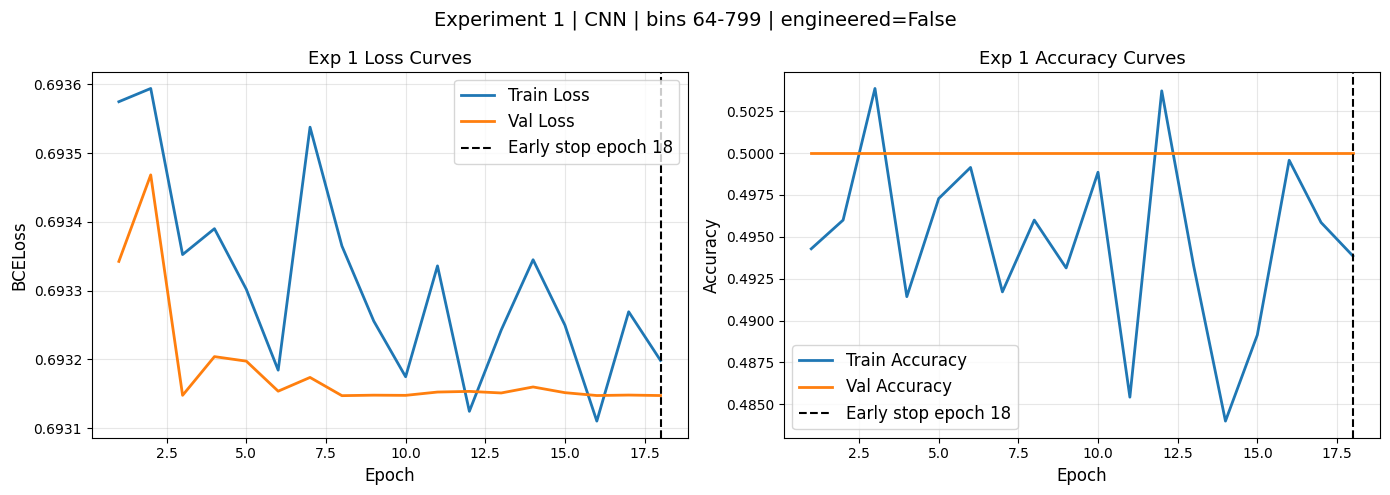


Experiment 2: CNN | bins (64, 150) | engineered=False
Computed CNN N_BLOCKS: 4
Trainable parameters: 838,017
Epoch  10 | train_loss=0.6932 acc=0.5013 | val_loss=0.6932 acc=0.5000
Epoch  20 | train_loss=0.6931 acc=0.4994 | val_loss=0.6931 acc=0.5000
Early stopping triggered at epoch 24
Test metrics @ optimal threshold inf:
  Accuracy=0.5000, Precision=0.0000, Recall=0.0000, F1=0.0000, AUC=0.5000


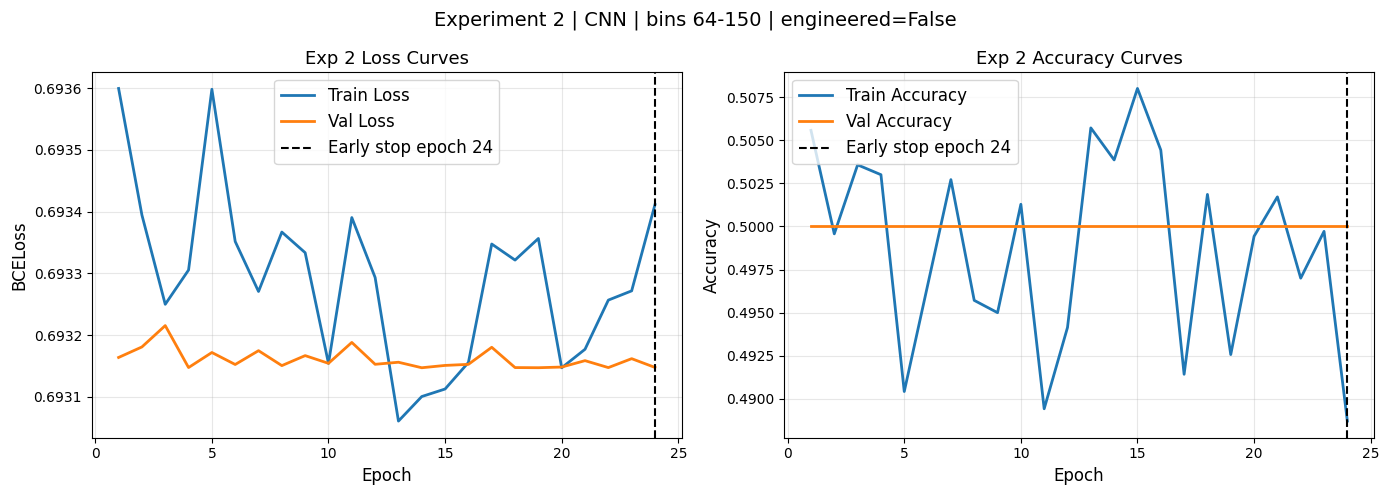


Experiment 3: DNN | bins (64, 799) | engineered=False
Trainable parameters: 1,443,841
Epoch  10 | train_loss=0.6946 acc=0.4917 | val_loss=0.6933 acc=0.5000
Epoch  20 | train_loss=0.6936 acc=0.4970 | val_loss=0.6943 acc=0.5000
Early stopping triggered at epoch 21
Test metrics @ optimal threshold 0.5002:
  Accuracy=0.5047, Precision=0.5024, Recall=0.9707, F1=0.6621, AUC=0.4682


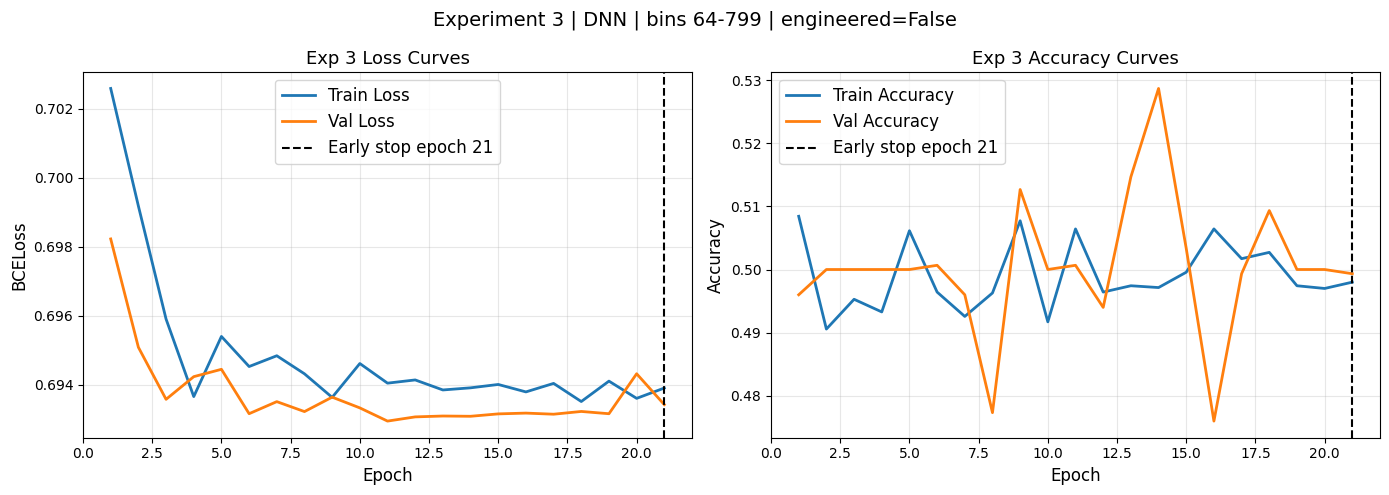


Experiment 4: DNN | bins (64, 799) | engineered=True
Trainable parameters: 1,449,985
Epoch  10 | train_loss=0.6942 acc=0.4966 | val_loss=0.6935 acc=0.5000
Early stopping triggered at epoch 11
Test metrics @ optimal threshold 0.4869:
  Accuracy=0.5013, Precision=0.5007, Recall=1.0000, F1=0.6673, AUC=0.4697


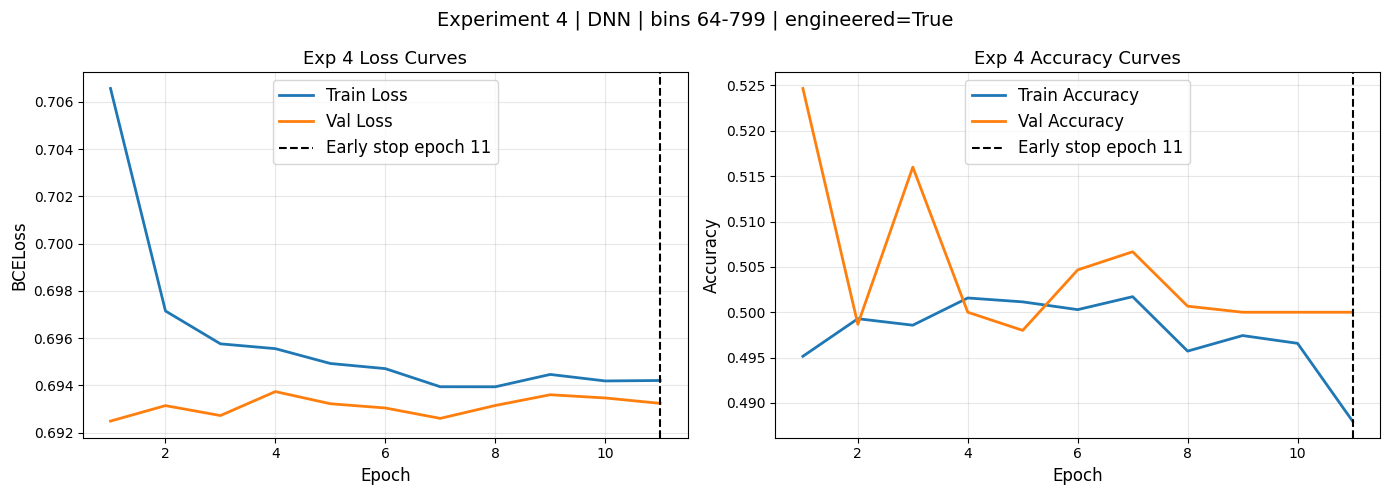


Experiment 5: DNN | bins (64, 150) | engineered=False
Trainable parameters: 779,265
Epoch  10 | train_loss=0.6937 acc=0.5029 | val_loss=0.6938 acc=0.4860
Early stopping triggered at epoch 13
Test metrics @ optimal threshold 0.5034:
  Accuracy=0.5053, Precision=0.5038, Recall=0.7027, F1=0.5869, AUC=0.4829


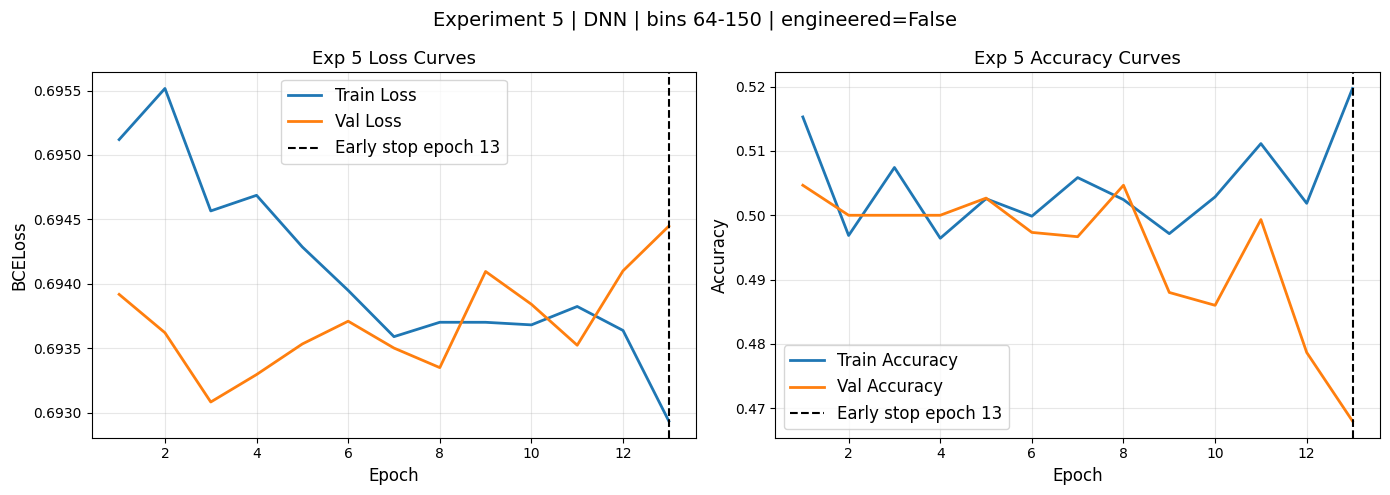


Experiment 6: DNN | bins (64, 150) | engineered=True
Trainable parameters: 785,409
Epoch  10 | train_loss=0.6937 acc=0.5113 | val_loss=0.6936 acc=0.4853
Early stopping triggered at epoch 18
Test metrics @ optimal threshold 0.4900:
  Accuracy=0.5060, Precision=0.5044, Recall=0.6947, F1=0.5844, AUC=0.4745


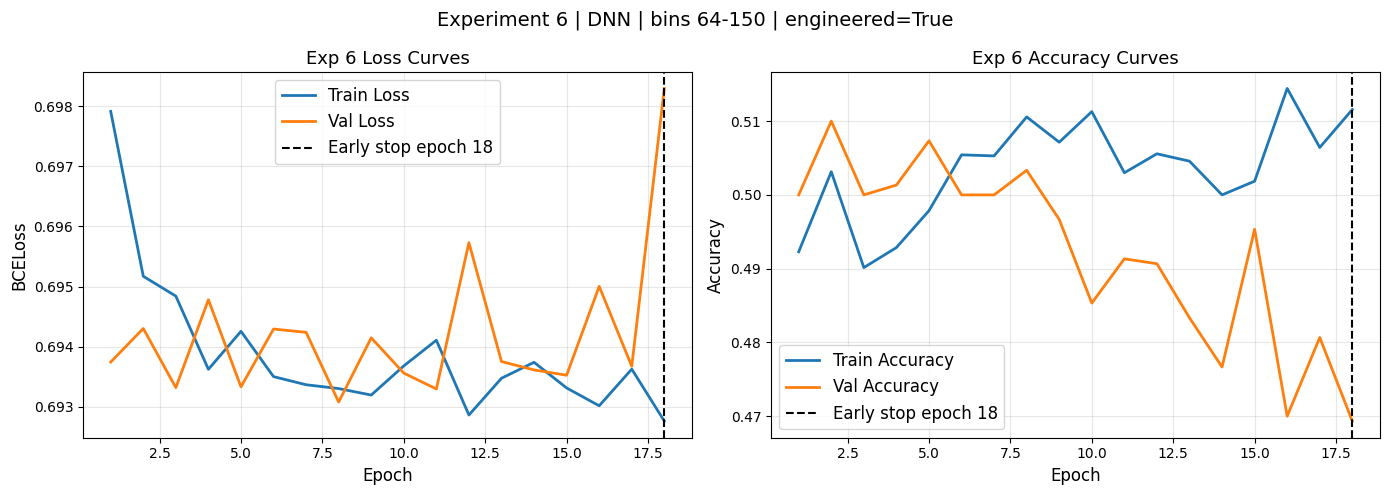

In [ ]:
# Section 5: Train all required experiments and collect metrics/ROC artifacts
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
criterion = nn.BCELoss()
results = []
roc_artifacts = {}

for exp in experiments:
    print(f"\n{'='*60}")
    print(f"Experiment {exp['id']}: {exp['model_type']} | bins {exp['bins']} | engineered={exp['use_engineered']}")
    print(f"{'='*60}")

    b_start, b_end = exp['bins']
    X_raw = X_all_bins[:, b_start:b_end + 1]

    train_loader, val_loader, test_loader, scaler = build_dataloaders(
        X_raw=X_raw,
        X_eng=engineered_features,
        y=y,
        train_idx=train_idx,
        val_idx=val_idx,
        test_idx=test_idx,
        use_engineered=exp['use_engineered'],
        model_type=exp['model_type'],
        batch_size=BATCH_SIZE
    )

    sample_input, _ = next(iter(train_loader))
    input_dim = int(sample_input.shape[-1]) if exp['model_type'] == 'CNN' else int(sample_input.shape[1])

    if exp['model_type'] == 'CNN':
        model = CNN1D(input_length=X_raw.shape[1], dropout_rate=DROPOUT_RATE).to(device)
        print(f"Computed CNN N_BLOCKS: {model.n_blocks}")
    else:
        model = DNN(input_size=sample_input.shape[1], dropout_rate=DROPOUT_RATE).to(device)

    model.apply(init_weights)

    n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"Trainable parameters: {n_params:,}")

    optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', factor=0.5, patience=5, verbose=True
    )

    best_model_path = f"best_model_exp{exp['id']}.pt"
    early_stopping = EarlyStopping(patience=PATIENCE, path=best_model_path)

    train_losses, val_losses = [], []
    train_accs, val_accs = [], []
    stop_epoch = None

    for epoch in range(1, EPOCHS + 1):
        tl, ta = train_one_epoch(model, train_loader, optimizer, criterion, device)
        vl, va, _, _ = evaluate(model, val_loader, criterion, device)
        scheduler.step(vl)

        train_losses.append(tl)
        val_losses.append(vl)
        train_accs.append(ta)
        val_accs.append(va)

        should_stop = early_stopping(vl, model)
        current_lr = optimizer.param_groups[0]['lr']

        if epoch % 10 == 0:
            print(
                f"Epoch {epoch:3d} | train_loss={tl:.4f} acc={ta:.4f} | "
                f"val_loss={vl:.4f} acc={va:.4f} | lr={current_lr:.2e}"
            )

        if should_stop:
            stop_epoch = epoch
            print(f"Early stopping triggered at epoch {epoch}")
            break

    epochs_trained = len(train_losses)

    early_stopping.load_best(model)
    if os.path.exists(best_model_path):
        os.remove(best_model_path)

    test_loss, test_acc_05, y_pred_05, y_proba = evaluate(model, test_loader, criterion, device)
    y_true = y[test_idx].astype(int)

    optimal_threshold, optimal_accuracy = find_optimal_threshold(y_true, y_proba)
    y_pred_opt = (y_proba >= optimal_threshold).astype(int)

    precision = precision_score(y_true, y_pred_opt, zero_division=0)
    recall = recall_score(y_true, y_pred_opt, zero_division=0)
    f1 = f1_score(y_true, y_pred_opt, zero_division=0)
    auc_roc = roc_auc_score(y_true, y_proba)

    fpr, tpr, _ = roc_curve(y_true, y_proba)

    result = {
        'experiment_id': exp['id'],
        'model_type': exp['model_type'],
        'bin_range': f"{exp['bins'][0]}-{exp['bins'][1]}",
        'use_engineered': exp['use_engineered'],
        'n_input_features': input_dim,
        'epochs_trained': epochs_trained,
        'optimal_threshold': optimal_threshold,
        'accuracy': optimal_accuracy,
        'precision': precision,
        'recall': recall,
        'f1': f1,
        'auc_roc': auc_roc
    }
    results.append(result)

    roc_artifacts[exp['id']] = {
        'fpr': fpr,
        'tpr': tpr,
        'auc': auc_roc,
        'y_true': y_true,
        'y_proba': y_proba,
        'y_pred_opt': y_pred_opt,
        'optimal_threshold': optimal_threshold,
        'config': exp
    }

    print(f"Test metrics @ optimal threshold {optimal_threshold:.4f}:")
    print(f"  Accuracy={optimal_accuracy:.4f}, Precision={precision:.4f}, Recall={recall:.4f}, F1={f1:.4f}, AUC={auc_roc:.4f}")

    epochs_axis = np.arange(1, epochs_trained + 1)
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    axes[0].plot(epochs_axis, train_losses, label='Train Loss', linewidth=2)
    axes[0].plot(epochs_axis, val_losses, label='Val Loss', linewidth=2)
    if stop_epoch is not None:
        axes[0].axvline(stop_epoch, color='black', linestyle='--', linewidth=1.5, label=f'Early stop epoch {stop_epoch}')
    axes[0].set_title(f"Exp {exp['id']} Loss Curves", fontsize=13)
    axes[0].set_xlabel('Epoch', fontsize=12)
    axes[0].set_ylabel('BCELoss', fontsize=12)
    axes[0].legend(fontsize=12)
    axes[0].grid(alpha=0.3)

    axes[1].plot(epochs_axis, train_accs, label='Train Accuracy', linewidth=2)
    axes[1].plot(epochs_axis, val_accs, label='Val Accuracy', linewidth=2)
    if stop_epoch is not None:
        axes[1].axvline(stop_epoch, color='black', linestyle='--', linewidth=1.5, label=f'Early stop epoch {stop_epoch}')
    axes[1].set_title(f"Exp {exp['id']} Accuracy Curves", fontsize=13)
    axes[1].set_xlabel('Epoch', fontsize=12)
    axes[1].set_ylabel('Accuracy', fontsize=12)
    axes[1].legend(fontsize=12)
    axes[1].grid(alpha=0.3)

    fig.suptitle(
        f"Experiment {exp['id']} | {exp['model_type']} | bins {exp['bins'][0]}-{exp['bins'][1]} | engineered={exp['use_engineered']}",
        fontsize=14
    )
    plt.tight_layout()
    plt.show()

## Section 6 — Results Table

All deep learning experiment results are aggregated, sorted by AUC-ROC, and compared against fixed reference baselines from traditional ML and threshold testing.

In [11]:
# Section 6: Build comparison table with reference baselines and print key interpretation points
results_df = pd.DataFrame(results)
results_df_sorted = results_df.sort_values('auc_roc', ascending=False).reset_index(drop=True)

reference_rows = pd.DataFrame([
    {"experiment_id": "REF-1", "model_type": "SVM (RBF)", "bin_range": "64-150", "use_engineered": False,
     "accuracy": 0.2785, "auc_roc": 0.7925},
    {"experiment_id": "REF-2", "model_type": "Threshold Test", "bin_range": "64-83", "use_engineered": False,
     "accuracy": 0.5000, "auc_roc": 0.4876}
])

comparison_df = pd.concat([reference_rows, results_df_sorted], ignore_index=True, sort=False)
display_cols = [
    'experiment_id', 'model_type', 'bin_range', 'use_engineered', 'n_input_features',
    'epochs_trained', 'optimal_threshold', 'accuracy', 'precision', 'recall', 'f1', 'auc_roc'
]
display(comparison_df[display_cols])

best_row = results_df_sorted.iloc[0]
best_auc = best_row['auc_roc']
best_exp_id = int(best_row['experiment_id'])
svm_auc = 0.7925

wide_df = results_df[results_df['bin_range'] == '64-799']
narrow_df = results_df[results_df['bin_range'] == '64-150']
wide_mean_auc = wide_df['auc_roc'].mean()
narrow_mean_auc = narrow_df['auc_roc'].mean()

eng_df = results_df[results_df['use_engineered'] == True]
raw_df = results_df[results_df['use_engineered'] == False]
eng_mean_auc = eng_df['auc_roc'].mean() if len(eng_df) > 0 else np.nan
raw_mean_auc = raw_df['auc_roc'].mean()

print("Interpretation summary:")
print(f"- Highest AUC experiment: Exp {best_exp_id} ({best_row['model_type']}, bins {best_row['bin_range']}, engineered={best_row['use_engineered']}) with AUC={best_auc:.4f}")
print(f"- DNN beats SVM AUC 0.79? {'Yes' if results_df[(results_df['model_type']=='DNN') & (results_df['auc_roc'] > svm_auc)].shape[0] > 0 else 'No'}")
print(f"- Mean AUC wide bins (64-799): {wide_mean_auc:.4f} vs narrow bins (64-150): {narrow_mean_auc:.4f}")
print(f"- Mean AUC with engineered: {eng_mean_auc:.4f} vs raw-only: {raw_mean_auc:.4f}")
print("- These comparisons indicate whether information is concentrated near 64-150 or distributed into farther out-of-band bins.")

,experiment_id,model_type,bin_range,use_engineered,n_input_features,epochs_trained,optimal_threshold,accuracy,precision,recall,f1,auc_roc
0,REF-1,SVM (RBF),64-150,False,NaN,NaN,NaN,0.278500,NaN,NaN,NaN,0.792500
1,REF-2,Threshold Test,64-83,False,NaN,NaN,NaN,0.500000,NaN,NaN,NaN,0.487600
2,1,CNN,64-799,False,736.0,18.0,0.499877,0.500667,0.500334,1.000000,0.666963,0.500667
3,2,CNN,64-150,False,87.0,24.0,inf,0.500000,0.000000,0.000000,0.000000,0.500000
4,5,DNN,64-150,False,87.0,13.0,0.503434,0.505333,0.503824,0.702667,0.586860,0.482933
5,6,DNN,64-150,True,93.0,18.0,0.489998,0.506000,0.504356,0.694667,0.584408,0.474545
6,4,DNN,64-799,True,742.0,11.0,0.486872,0.501333,0.500668,1.000000,0.667260,0.469663
7,3,DNN,64-799,False,736.0,21.0,0.500175,0.504667,0.502415,0.970667,0.662119,0.468190


Interpretation summary:
- Highest AUC experiment: Exp 1 (CNN, bins 64-799, engineered=False) with AUC=0.5007
- DNN beats SVM AUC 0.79? No
- Mean AUC wide bins (64-799): 0.4795 vs narrow bins (64-150): 0.4858
- Mean AUC with engineered: 0.4721 vs raw-only: 0.4879
- These comparisons indicate whether information is concentrated near 64-150 or distributed into farther out-of-band bins.


### Results Interpretation

Use the table and summary above to answer the thesis questions:
- Which experiment achieved the highest AUC?
- Did any DNN experiment exceed SVM AUC = 0.7925?
- Did wider bins (`64–799`) improve over narrower bins (`64–150`)?
- Did engineered features improve or degrade DNN results?
- What does this imply about distributed nonlinear information in spectral regrowth?

## Section 7 — Results Visualization

A 2×2 figure summarizes ranking performance, threshold-level accuracy, ROC behavior, and an AUC heatmap across model families and configurations.

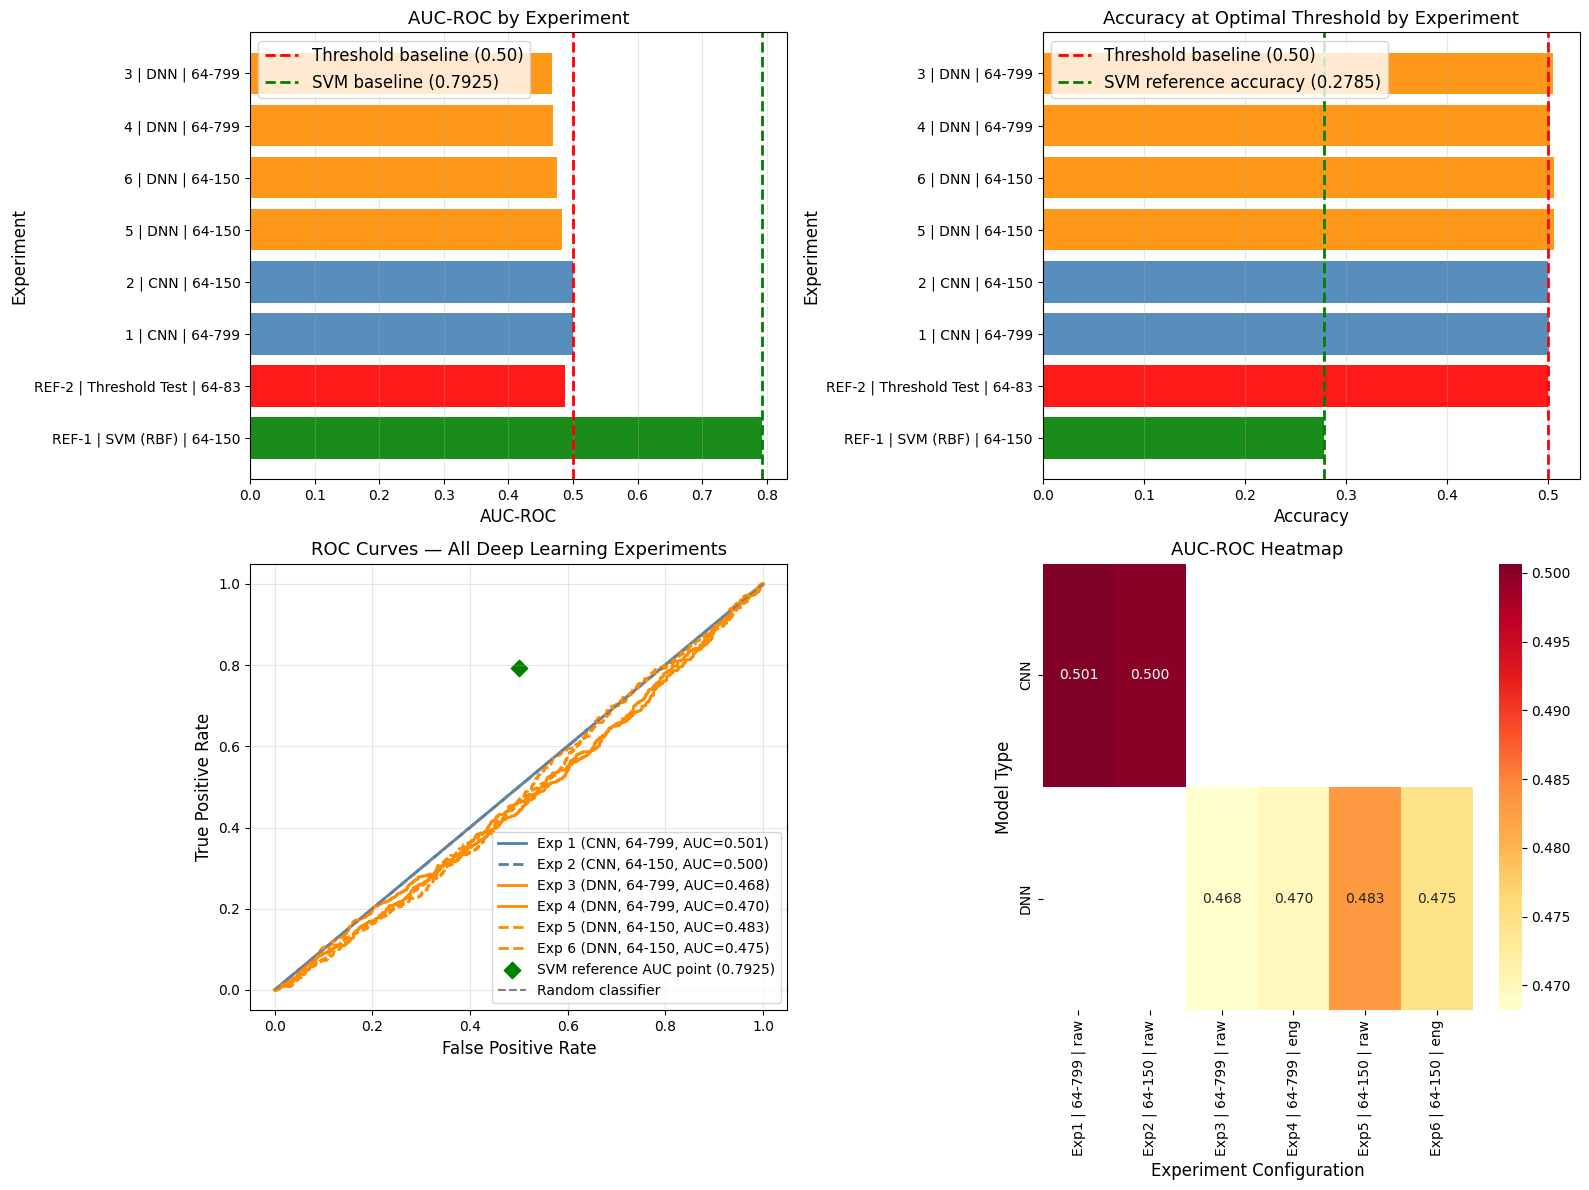

In [12]:
# Section 7: Create 2x2 visualization panel for aggregate performance analysis
viz_df = comparison_df.copy()
viz_df['label'] = viz_df.apply(lambda r: f"{r['experiment_id']} | {r['model_type']} | {r['bin_range']}", axis=1)

def row_color(model_type):
    if model_type == 'CNN':
        return 'steelblue'
    if model_type == 'DNN':
        return 'darkorange'
    if model_type == 'SVM (RBF)':
        return 'green'
    if model_type == 'Threshold Test':
        return 'red'
    return 'gray'

colors = [row_color(m) for m in viz_df['model_type']]

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Plot 1: AUC horizontal bars
ax = axes[0, 0]
ax.barh(viz_df['label'], viz_df['auc_roc'], color=colors, alpha=0.9)
ax.axvline(0.50, color='red', linestyle='--', linewidth=2, label='Threshold baseline (0.50)')
ax.axvline(0.7925, color='green', linestyle='--', linewidth=2, label='SVM baseline (0.7925)')
ax.set_title('AUC-ROC by Experiment', fontsize=13)
ax.set_xlabel('AUC-ROC', fontsize=12)
ax.set_ylabel('Experiment', fontsize=12)
ax.legend(fontsize=12)
ax.grid(axis='x', alpha=0.3)

# Plot 2: Accuracy horizontal bars
ax = axes[0, 1]
acc_vals = viz_df['accuracy'].fillna(np.nan)
ax.barh(viz_df['label'], acc_vals, color=colors, alpha=0.9)
ax.axvline(0.50, color='red', linestyle='--', linewidth=2, label='Threshold baseline (0.50)')
ax.axvline(0.2785, color='green', linestyle='--', linewidth=2, label='SVM reference accuracy (0.2785)')
ax.set_title('Accuracy at Optimal Threshold by Experiment', fontsize=13)
ax.set_xlabel('Accuracy', fontsize=12)
ax.set_ylabel('Experiment', fontsize=12)
ax.legend(fontsize=12)
ax.grid(axis='x', alpha=0.3)

# Plot 3: ROC curves for all deep experiments
ax = axes[1, 0]
for exp in experiments:
    art = roc_artifacts[exp['id']]
    model_color = 'steelblue' if exp['model_type'] == 'CNN' else 'darkorange'
    ls = '-' if exp['bins'] == (64, 799) else '--'
    ax.plot(
        art['fpr'],
        art['tpr'],
        color=model_color,
        linestyle=ls,
        linewidth=2,
        label=f"Exp {exp['id']} ({exp['model_type']}, {exp['bins'][0]}-{exp['bins'][1]}, AUC={art['auc']:.3f})"
    )

ax.scatter([0.5], [0.7925], color='green', s=70, marker='D', label='SVM reference AUC point (0.7925)')
ax.plot([0, 1], [0, 1], color='gray', linestyle='--', linewidth=1.5, label='Random classifier')
ax.set_title('ROC Curves — All Deep Learning Experiments', fontsize=13)
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.legend(fontsize=10, loc='lower right')
ax.grid(alpha=0.3)

# Plot 4: AUC heatmap
ax = axes[1, 1]
heat_df = results_df.copy()
heat_df['config'] = heat_df.apply(
    lambda r: f"Exp{int(r['experiment_id'])} | {r['bin_range']} | {'eng' if r['use_engineered'] else 'raw'}", axis=1
)
heat_pivot = heat_df.pivot_table(index='model_type', columns='config', values='auc_roc', aggfunc='mean')
heat_pivot = heat_pivot.reindex(index=['CNN', 'DNN'])
sns.heatmap(heat_pivot, annot=True, fmt='.3f', cmap='YlOrRd', cbar=True, ax=ax)
ax.set_title('AUC-ROC Heatmap', fontsize=13)
ax.set_xlabel('Experiment Configuration', fontsize=12)
ax.set_ylabel('Model Type', fontsize=12)

plt.tight_layout()
plt.show()

## Section 8 — Best Model Analysis

The highest-AUC deep experiment is analyzed in detail via confusion structure and probability separation between true classes.

ValueError: Too many bins for data range. Cannot create 30 finite-sized bins.

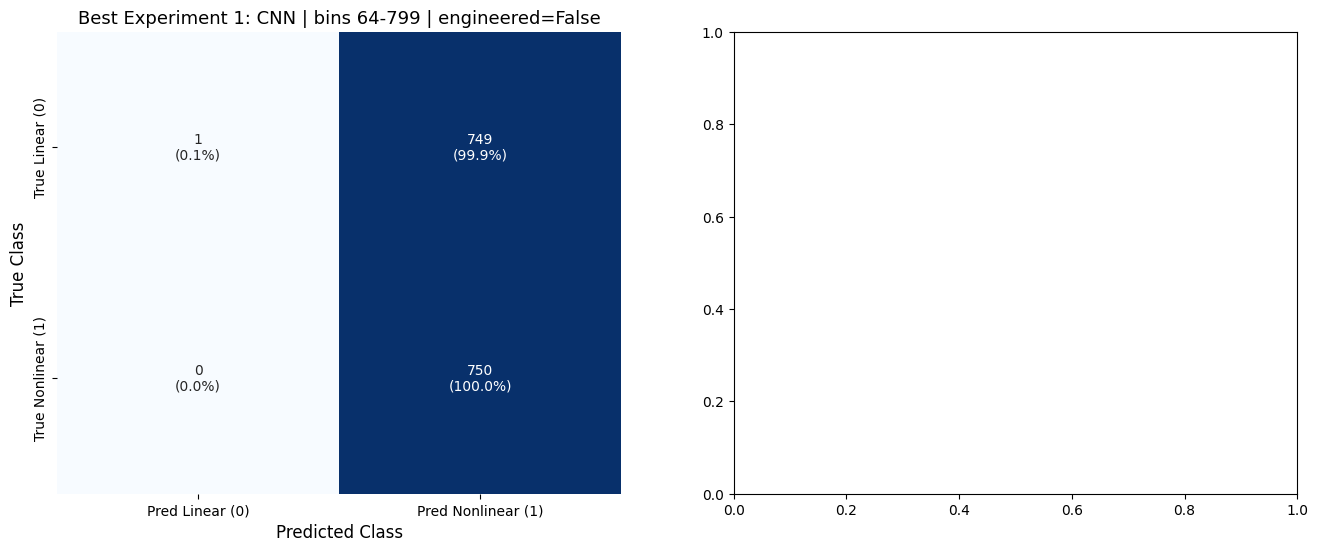

In [13]:
# Section 8: Analyze best deep model with confusion matrix and probability distributions
best_deep_row = results_df.sort_values('auc_roc', ascending=False).iloc[0]
best_exp_id = int(best_deep_row['experiment_id'])
best_art = roc_artifacts[best_exp_id]
best_cfg = best_art['config']

y_true_best = best_art['y_true']
y_pred_best = best_art['y_pred_opt']
y_proba_best = best_art['y_proba']
thr_best = best_art['optimal_threshold']

cm = confusion_matrix(y_true_best, y_pred_best)
cm_row_norm = cm / (cm.sum(axis=1, keepdims=True) + 1e-10)

annot = np.empty_like(cm, dtype=object)
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        annot[i, j] = f"{cm[i, j]}\n({cm_row_norm[i, j] * 100:.1f}%)"

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.heatmap(
    cm,
    annot=annot,
    fmt='',
    cmap='Blues',
    cbar=False,
    xticklabels=['Pred Linear (0)', 'Pred Nonlinear (1)'],
    yticklabels=['True Linear (0)', 'True Nonlinear (1)'],
    ax=axes[0]
)
axes[0].set_title(
    f"Best Experiment {best_exp_id}: {best_cfg['model_type']} | bins {best_cfg['bins'][0]}-{best_cfg['bins'][1]} | engineered={best_cfg['use_engineered']}",
    fontsize=13
)
axes[0].set_xlabel('Predicted Class', fontsize=12)
axes[0].set_ylabel('True Class', fontsize=12)

axes[1].hist(y_proba_best[y_true_best == 0], bins=30, alpha=0.65, label='True Linear (0)', color='steelblue')
axes[1].hist(y_proba_best[y_true_best == 1], bins=30, alpha=0.65, label='True Nonlinear (1)', color='darkorange')
axes[1].axvline(thr_best, color='black', linestyle='--', linewidth=2, label=f'Optimal threshold={thr_best:.3f}')
axes[1].set_title('Predicted Probability Distribution by True Class', fontsize=13)
axes[1].set_xlabel('Predicted Probability', fontsize=12)
axes[1].set_ylabel('Count', fontsize=12)
axes[1].legend(fontsize=12)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

### Final Thesis Summary

After running the notebook, interpret outcomes in this order:
1. **Deep learning vs threshold test:** compare best deep model metrics to threshold baseline (AUC 0.4876, accuracy 0.5000).
2. **Deep learning vs SVM:** compare best deep AUC to SVM AUC 0.7925.
3. **Best architecture/configuration:** identify the highest-AUC experiment and its bin span / engineered-feature setting.
4. **Implications for signal physics:** assess whether useful class information is localized near 64–150 or spread into farther out-of-band bins.
5. **Next steps:** test increased OSR to expose additional bins, alternative architectures (residual 1D CNN, attention, or hybrid CNN-MLP), and calibration/regularization refinements for weak distributed effects.